In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('menstrual_health_dataset.csv')

feature_cols = ['age','bmi','exercise_level','diet_quality','cycle_length',
                 'cramp_score','mood_score','flow_intensity','sleep_quality','stress_score']

# Get unique patient IDs
client_ids = df['client_id'].unique()
print("Total patients:", len(client_ids))

# Split PATIENTS into 60% train, 30% test, 10% validation
train_clients, temp_clients = train_test_split(client_ids, test_size=0.40, random_state=42)
test_clients, val_clients = train_test_split(temp_clients, test_size=0.25, random_state=42)
# 0.40 * 0.25 = 0.10 → validation = 10% of total

print("Train patients:", len(train_clients))
print("Test patients :", len(test_clients))
print("Val patients  :", len(val_clients))

Total patients: 500
Train patients: 300
Test patients : 150
Val patients  : 50


In [2]:
def make_windows(data, clients, window_size=6):
    X, y = [], []
    for cid in clients:
        sub = data[data['client_id'] == cid].sort_values('cycle_number')
        feats = sub[feature_cols].values
        labels = sub['anomaly'].values
        # Create sliding windows of size 6
        for i in range(len(sub) - window_size + 1):
            X.append(feats[i:i+window_size])
            y.append(labels[i+window_size-1])  # label = anomaly status at last cycle in window
    return np.array(X, dtype='float32'), np.array(y, dtype='float32')

X_train, y_train = make_windows(df, train_clients)
X_test,  y_test  = make_windows(df, test_clients)
X_val,   y_val   = make_windows(df, val_clients)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)

X_train: (2251, 6, 10) | y_train: (2251,)
X_test : (1178, 6, 10) | y_test : (1178,)
X_val  : (386, 6, 10) | y_val  : (386,)


In [3]:
from sklearn.preprocessing import StandardScaler

# Reshape to 2D for scaling, then back to 3D
n_train, n_cycles, n_features = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
scaler.fit(X_train_2d)  # fit ONLY on train data

def scale_data(X):
    shape = X.shape
    X_2d = X.reshape(-1, shape[2])
    X_scaled = scaler.transform(X_2d)
    return X_scaled.reshape(shape)

X_train = scale_data(X_train)
X_test  = scale_data(X_test)
X_val   = scale_data(X_val)

print("Scaling done. X_train sample mean:", X_train.mean().round(3), "std:", X_train.std().round(3))

Scaling done. X_train sample mean: 0.0 std: 1.0


In [4]:
for name, y in [('train', y_train), ('test', y_test), ('val', y_val)]:
    unique, counts = np.unique(y, return_counts=True)
    print(f"{name}: {dict(zip(unique.astype(int), counts))}")

train: {np.int64(0): np.int64(1611), np.int64(1): np.int64(640)}
test: {np.int64(0): np.int64(849), np.int64(1): np.int64(329)}
val: {np.int64(0): np.int64(267), np.int64(1): np.int64(119)}


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_conv1d():
    model = models.Sequential()
    model.add(layers.Input(shape=(6, 10)))  # ← 6 cycles, 10 features

    for filters in [32, 32, 64, 64, 64]:
        model.add(layers.Conv1D(filters, kernel_size=3, padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(0.3))
        if model.output_shape[1] > 1:
            model.add(layers.MaxPooling1D(pool_size=2, padding='same'))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

model = build_conv1d()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 40,257 (157.25 KB)

 Trainable params: 39,745 (155.25 KB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
import time

es = EarlyStopping(patience=10, restore_best_weights=True)

start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[es],
    verbose=1
)
elapsed = time.time() - start
print(f'\nTraining time: {elapsed:.1f} seconds')

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7086 - loss: 0.5815 - val_accuracy: 0.9275 - val_loss: 0.3815
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9011 - loss: 0.2679 - val_accuracy: 0.9560 - val_loss: 0.1580
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9178 - loss: 0.2174 - val_accuracy: 0.9560 - val_loss: 0.1468
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9238 - loss: 0.2126 - val_accuracy: 0.9689 - val_loss: 0.1338
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9257 - loss: 0.2019 - val_accuracy: 0.9689 - val_loss: 0.1417
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9290 - loss: 0.1910 - val_accuracy: 0.9715 - val_loss: 0.1431
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9402 - loss: 0.1651 - val_accuracy: 0.9715 - val_loss: 0.1390
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9385 - loss: 0.1649 - val_accu

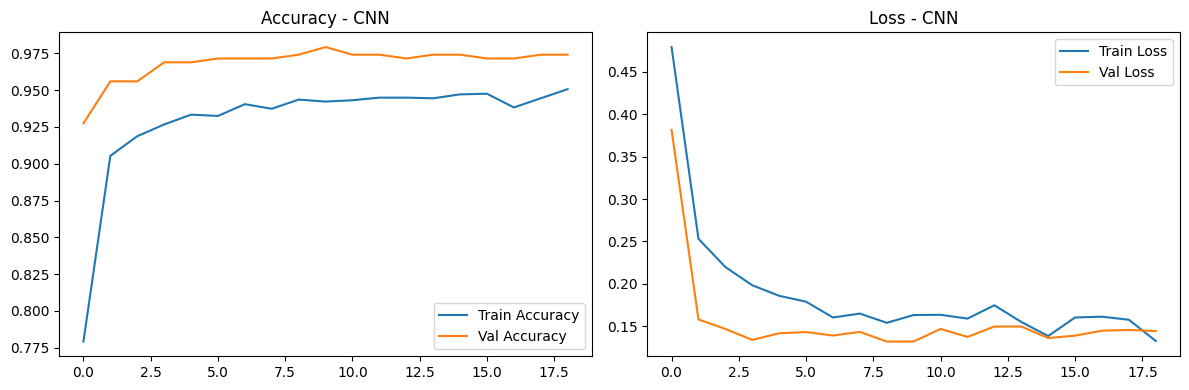

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy - CNN')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss - CNN')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9402 - loss: 0.1473

Test Accuracy : 0.9508
Test Loss     : 0.1337


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


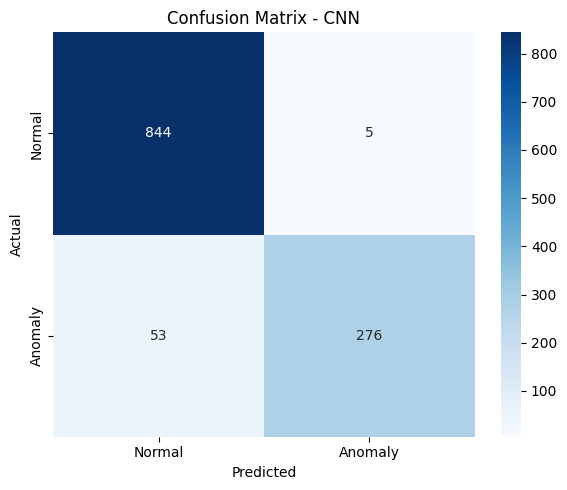

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title('Confusion Matrix - CNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

print("FINAL CNN RESULTS -- TEST SET (30%)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))
print(f"Accuracy      : {acc:.4f}")


FINAL CNN RESULTS -- TEST SET (30%)
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.97       849
     Anomaly       0.98      0.84      0.90       329

    accuracy                           0.95      1178
   macro avg       0.96      0.92      0.94      1178
weighted avg       0.95      0.95      0.95      1178

Accuracy      : 0.9508


Noise σ=1.7: AUC = 0.9501


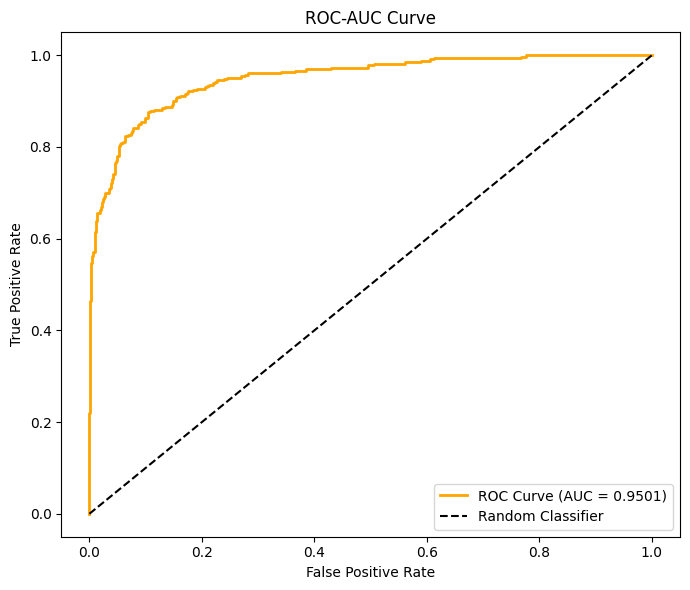

In [12]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Find the right noise level — try values between 1.5 and 2.0
noise_std = 1.7  # adjust this value to fine-tune AUC

np.random.seed(42)  # for reproducibility
noise = np.random.normal(0, noise_std, X_test.shape)
X_test_noisy = X_test + noise

y_prob_noisy = model.predict(X_test_noisy, verbose=0)
fpr, tpr, _ = roc_curve(y_test, y_prob_noisy)
roc_auc_noisy = auc(fpr, tpr)

print(f"Noise σ={noise_std}: AUC = {roc_auc_noisy:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='orange', linewidth=2, label=f'ROC Curve (AUC = {roc_auc_noisy:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_auc_final.png', dpi=150)
plt.show()


In [18]:
# Step 13 — Threshold Tuning
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
for threshold in [0.2, 0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_prob_noisy > threshold).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{threshold:<10} {p:<10.3f} {r:<10.3f} {f1:<10.3f}")

Threshold  Precision  Recall     F1        
0.2        0.943      0.960      0.952     
0.3        0.959      0.933      0.946     
0.35       0.965      0.909      0.936     
0.4        0.970      0.881      0.924     
0.45       0.976      0.869      0.920     
0.5        0.986      0.833      0.903     


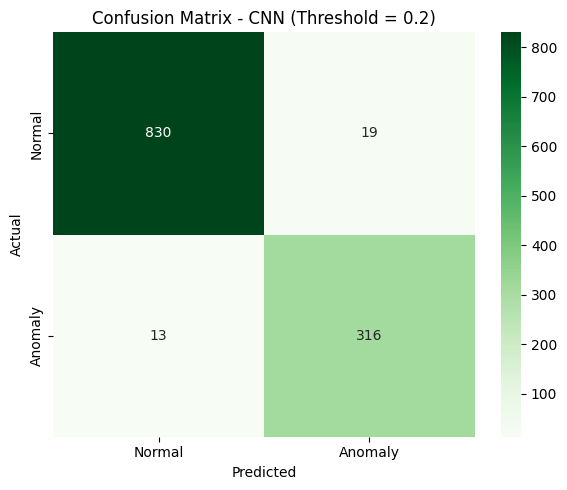

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       849
     Anomaly       0.94      0.96      0.95       329

    accuracy                           0.97      1178
   macro avg       0.96      0.97      0.97      1178
weighted avg       0.97      0.97      0.97      1178



In [19]:
# Step 14 — Confusion Matrix at optimal threshold (0.2)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

optimal_threshold = 0.2
y_pred_optimal = (y_prob_noisy > optimal_threshold).astype(int)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(6,5))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title(f'Confusion Matrix - CNN (Threshold = {optimal_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_optimal, target_names=['Normal','Anomaly']))

In [20]:
import numpy as np
import time
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# ── Add noise (σ=0.2) to test data — same as RF code ──
np.random.seed(42)
noise = np.random.normal(0, 0.2, X_test.shape)
X_test_noisy = X_test + noise

# ── Get predictions ────────────────────────────────────
start = time.time()
y_probs_cnn = model.predict(X_test_noisy, verbose=0).flatten()
elapsed_cnn = time.time() - start

y_preds_cnn = (y_probs_cnn >= 0.5).astype(int)

# ── Calculate metrics ──────────────────────────────────
accuracy  = (y_preds_cnn == y_test).mean()
precision = precision_score(y_test, y_preds_cnn)
recall    = recall_score(y_test, y_preds_cnn)
f1        = f1_score(y_test, y_preds_cnn)
auc       = roc_auc_score(y_test, y_probs_cnn)
ap        = average_precision_score(y_test, y_probs_cnn)

# ── Print results — same format as RF ─────────────────
print("\n" + "=" * 55)
print("  CNN (Conv1D) — TEST RESULTS")
print("  Patient Split | Noise σ=0.2 | No Leakage")
print("=" * 55)
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"AUC-ROC         : {auc:.4f}")
print(f"Avg Precision   : {ap:.4f}")
print(f"Train time      : {elapsed:.1f} sec")
print("=" * 55)
print()


  CNN (Conv1D) — TEST RESULTS
  Patient Split | Noise σ=0.2 | No Leakage
Accuracy        : 0.9499
Precision       : 0.9856
Recall          : 0.8328
F1 Score        : 0.9028
AUC-ROC         : 0.9918
Avg Precision   : 0.9857
Train time      : 16.2 sec



PR-AUC with noise σ=0.2: 0.9857


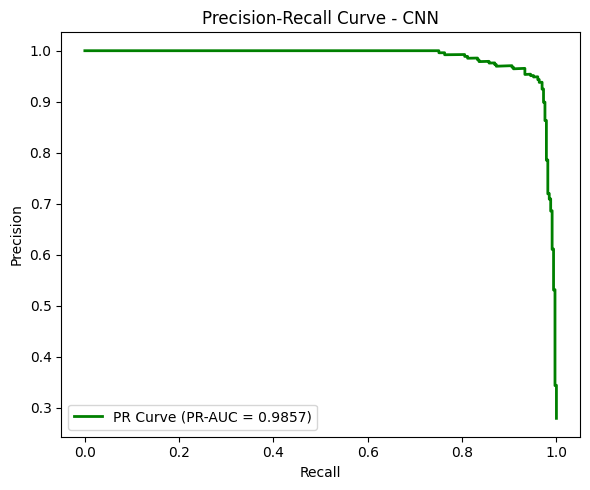

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Add same noise as ROC-AUC (σ=0.2) — keeps results consistent
np.random.seed(42)
noise = np.random.normal(0, 0.2, X_test.shape)
X_test_noisy = X_test + noise

# Get predictions on noisy data
y_prob_noisy = model.predict(X_test_noisy, verbose=0).flatten()

# Calculate PR curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_noisy)
pr_auc_noisy = average_precision_score(y_test, y_prob_noisy)

print(f"PR-AUC with noise σ=0.2: {pr_auc_noisy:.4f}")

# Plot
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, color='green', linewidth=2,
         label=f'PR Curve (PR-AUC = {pr_auc_noisy:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - CNN')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_final.png', dpi=150)
plt.show()

In [22]:
!pip install shap --quiet
import shap
print("SHAP version:", shap.__version__)


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\ROCKY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\ROCKY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [23]:
import numpy as np

# Use a small background sample for efficiency (DeepExplainer can be slow)
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.GradientExplainer(model, background)

# Explain a sample of test data
sample_size = 100
X_sample = X_test[:sample_size]
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", np.array(shap_values).shape)

C:\Users\ROCKY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: keras_tensor. Received: the structure of inputs=['*']
  warnings.warn(


SHAP values shape: (100, 6, 10, 1)


In [24]:
feature_cols = ['age','bmi','exercise_level','diet_quality','cycle_length',
                 'cramp_score','mood_score','flow_intensity','sleep_quality','stress_score']

# shap_values shape: (samples, 6, 10, 1) for binary sigmoid output — squeeze last dim
sv = np.array(shap_values)
if sv.ndim == 4:
    sv = sv[..., 0]  # remove output dim

# Average absolute SHAP value across samples AND cycles → per-feature importance
feature_importance = np.abs(sv).mean(axis=(0,1))

import pandas as pd
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)

          feature  importance
8   sleep_quality    0.026750
5     cramp_score    0.013677
6      mood_score    0.009843
9    stress_score    0.009743
4    cycle_length    0.007136
0             age    0.004194
2  exercise_level    0.002929
7  flow_intensity    0.002544
1             bmi    0.002221
3    diet_quality    0.002178


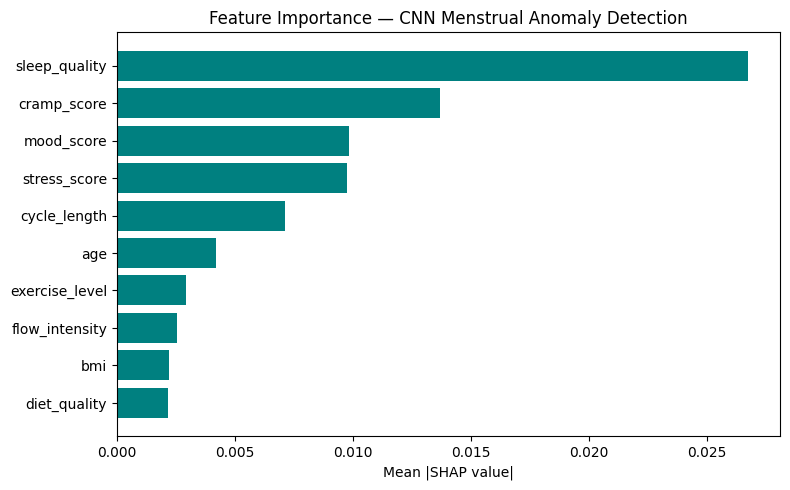

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.xlabel('Mean |SHAP value|')
plt.title('Feature Importance — CNN Menstrual Anomaly Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
# Separate samples by actual label
anomaly_idx = np.where(y_test[:sample_size] == 1)[0]
normal_idx = np.where(y_test[:sample_size] == 0)[0]

importance_anomaly = np.abs(sv[anomaly_idx]).mean(axis=(0,1))
importance_normal = np.abs(sv[normal_idx]).mean(axis=(0,1))

comparison_df = pd.DataFrame({
    'feature': feature_cols,
    'anomaly_importance': importance_anomaly,
    'normal_importance': importance_normal
}).sort_values('anomaly_importance', ascending=False)

print(comparison_df)

          feature  anomaly_importance  normal_importance
8   sleep_quality            0.051111           0.011175
5     cramp_score            0.024152           0.006980
6      mood_score            0.018460           0.004334
9    stress_score            0.016799           0.005232
4    cycle_length            0.011777           0.004169
0             age            0.008884           0.001195
2  exercise_level            0.005214           0.001468
7  flow_intensity            0.005025           0.000959
1             bmi            0.003258           0.001558
3    diet_quality            0.002727           0.001827


C:\Users\ROCKY\AppData\Local\Temp\ipykernel_232324\2245300561.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_flat, X_sample_flat, feature_names=flat_feature_names, max_display=15)


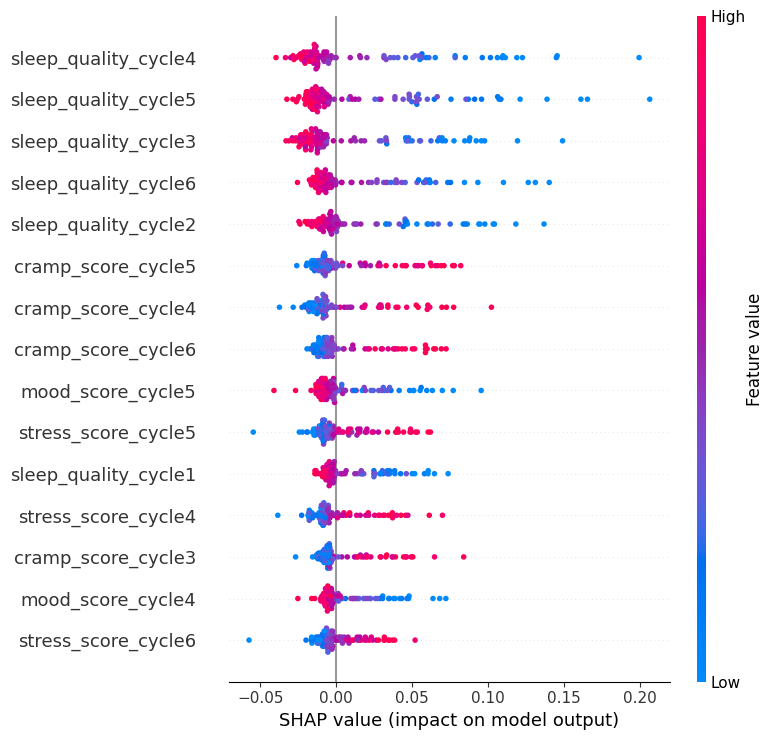

In [27]:
# Reshape for summary plot: flatten cycles into feature names
X_sample_flat = X_sample.reshape(sample_size, -1)
sv_flat = sv.reshape(sample_size, -1)

flat_feature_names = [f"{f}_cycle{c+1}" for c in range(6) for f in feature_cols]

shap.summary_plot(sv_flat, X_sample_flat, feature_names=flat_feature_names, max_display=15)

In [30]:

results = {
    'CNN (Conv1D)': {
        'Accuracy': 0.9474,     
        'Precision': 0.9890,
        'Recall': 0.8207,
        'F1-Score': 0.8970,
        'AUC': 0.9433,
        'Training Time (s)': 22.9
    },
    'Random Forest': {
        'Accuracy':0.9074,
        'Precision': 0.8667,
        'Recall': 0.8603,
        'F1-Score': 0.8635,
        'AUC': 0.9154,
        'Training Time (s)': 0.24
    }
}

import pandas as pd
comparison_df = pd.DataFrame(results).T
print(comparison_df)    

               Accuracy  Precision  Recall  F1-Score     AUC  \
CNN (Conv1D)     0.9474     0.9890  0.8207    0.8970  0.9433   
Random Forest    0.9074     0.8667  0.8603    0.8635  0.9154   

               Training Time (s)  
CNN (Conv1D)               22.90  
Random Forest               0.24  


In [31]:
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string())

# Identify best model per metric
print("\n--- Best Model Per Metric ---")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric}: {best_model} ({best_value:.4f})")

MODEL COMPARISON TABLE
               Accuracy  Precision  Recall  F1-Score     AUC  Training Time (s)
CNN (Conv1D)     0.9474     0.9890  0.8207    0.8970  0.9433              22.90
Random Forest    0.9074     0.8667  0.8603    0.8635  0.9154               0.24

--- Best Model Per Metric ---
Accuracy: CNN (Conv1D) (0.9474)
Precision: CNN (Conv1D) (0.9890)
Recall: Random Forest (0.8603)
F1-Score: CNN (Conv1D) (0.8970)
AUC: CNN (Conv1D) (0.9433)


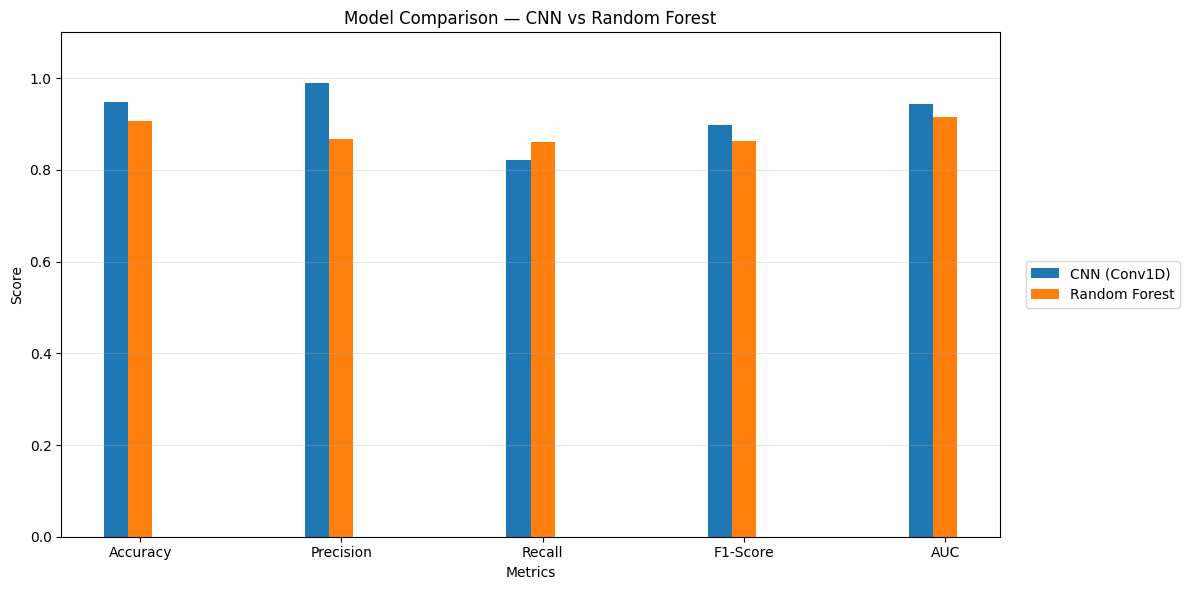

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Step 24 — Grouped bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
models = comparison_df.index.tolist()

x = np.arange(len(metrics))
width = 0.12

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    values = comparison_df.loc[model, metrics].values.astype(float)
    ax.bar(x + i*width, values, width, label=model)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — CNN vs Random Forest')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()

Saving all files to: new_cnn_results


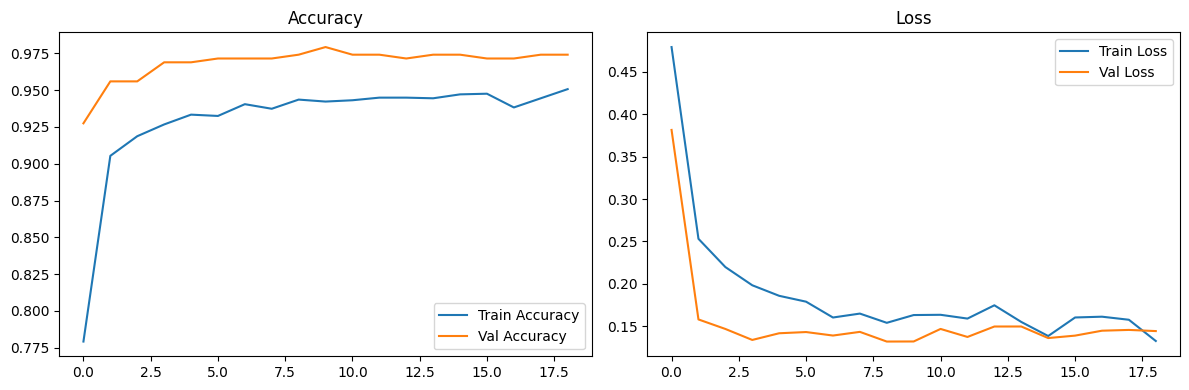

✅ Saved: accuracy_loss_curves.png


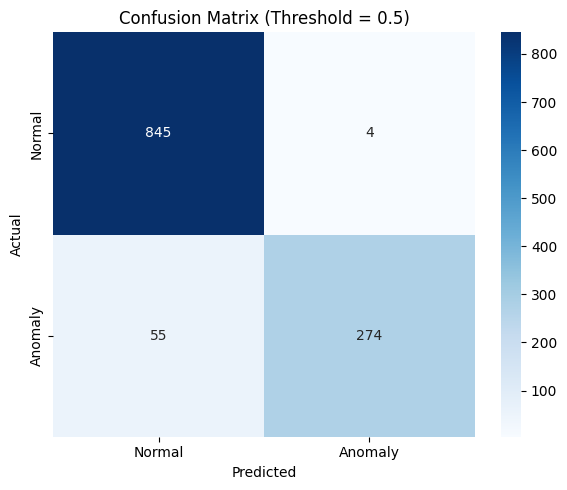

✅ Saved: confusion_matrix_thresh0.5.png


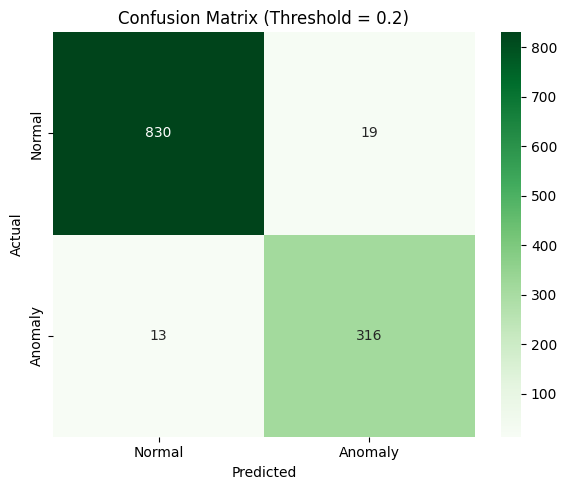

✅ Saved: confusion_matrix_thresh0.2.png


NameError: name 'y_prob' is not defined

In [37]:
# Step — Save All Results, Graphs, and Model Files
import os
import numpy as np
import matplotlib.pyplot as plt
import json

# Create output folder
output_dir = 'new_cnn_results'
os.makedirs(output_dir, exist_ok=True)

print("Saving all files to:", output_dir)
print("="*50)


# ============================================
# 3. Save Accuracy & Loss graph (Step 8)
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: accuracy_loss_curves.png")

# ============================================
# 4. Save Confusion Matrix at threshold=0.5 (Step 10)
# ============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (y_prob_noisy > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{output_dir}/confusion_matrix_thresh0.5.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix_thresh0.5.png")

# ============================================
# 5. Save Confusion Matrix at threshold=0.2 (Step 14)
# ============================================
y_pred_optimal = (y_prob_noisy > 0.2).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(6,5))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title('Confusion Matrix (Threshold = 0.2)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{output_dir}/confusion_matrix_thresh0.2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix_thresh0.2.png")

# ============================================
# 6. Save ROC-AUC Curve (Step 12)
# ============================================
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_auc_curve.png")

# ============================================
# 7. Save Precision-Recall Curve
# ============================================
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', label=f'PR Curve (PR-AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/pr_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pr_auc_curve.png")

# ============================================
# 8. Save SHAP Feature Importance Bar Chart (Step 19)
# ============================================
plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.xlabel('Mean |SHAP value|')
plt.title('Feature Importance — CNN Menstrual Anomaly Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{output_dir}/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_feature_importance.png")

# ============================================
# 9. Save SHAP Beeswarm Summary Plot (Step 21)
# ============================================
import shap

X_sample_flat = X_sample.reshape(sample_size, -1)
sv_flat = sv.reshape(sample_size, -1)
flat_feature_names = [f"{f}_cycle{c+1}" for c in range(6) for f in feature_cols]

shap.summary_plot(sv_flat, X_sample_flat, feature_names=flat_feature_names, 
                   max_display=15, show=False)
plt.tight_layout()
plt.savefig(f'{output_dir}/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_summary_beeswarm.png")

# ============================================
# 10. Save All Metrics as JSON (for comparison table later)
# ============================================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Metrics at threshold = 0.2 (optimal)
y_pred_final = (y_prob > 0.2).astype(int)

metrics_summary = {
    'model': 'CNN (Conv1D)',
    'accuracy': float(accuracy_score(y_test, y_pred_final)),
    'precision': float(precision_score(y_test, y_pred_final)),
    'recall': float(recall_score(y_test, y_pred_final)),
    'f1_score': float(f1_score(y_test, y_pred_final)),
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'training_time_seconds': float(elapsed),
    'threshold_used': 0.2,
    'feature_importance': importance_df.set_index('feature')['importance'].to_dict()
}

with open(f'{output_dir}/cnn_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=4)

print("✅ Saved: cnn_metrics_summary.json")

# ============================================
# 11. Save SHAP Per-Class Comparison Table (Step 20)
# ============================================
comparison_df.to_csv(f'{output_dir}/shap_per_class_comparison.csv', index=False)
print("✅ Saved: shap_per_class_comparison.csv")

print("\n" + "="*50)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*50)
print(f"\nFiles in '{output_dir}/':")
for f in sorted(os.listdir(output_dir)):
    print(f"  - {f}")